# 🎓 Decision Trees & Random Forests
## A University-Level Introduction to Tree-Based Machine Learning

---
> **Audience:** Undergraduate / postgraduate students with basic Python & statistics knowledge.  
> **Goal:** Build intuition, understand the mathematics, and apply these algorithms to a real classification problem.

---

### Learning Objectives
By the end of this notebook you will be able to:
1. Explain how a Decision Tree makes predictions
2. Define Gini Impurity and Information Gain
3. Describe why Random Forests outperform single trees
4. Train, evaluate, and tune both models using scikit-learn
5. Discuss the pros, cons, and appropriate use cases

## 1. Motivation — Why Tree-Based Methods?

Many real-world decisions are naturally tree-shaped. Consider diagnosing whether a student will pass an exam:

```
Did they attend > 70% of lectures?
├── YES: Did they complete > 80% of assignments?
│         ├── YES  → Likely to PASS 🎉
│         └── NO   → Borderline — depends on exam score
└── NO:  Did they have prior knowledge of the topic?
          ├── YES  → Borderline
          └── NO   → Likely to FAIL ❌
```

This kind of reasoning is:
- **Transparent** — you can explain every decision
- **Non-linear** — it captures interactions between features
- **Versatile** — works for classification AND regression

Machine learning **Decision Trees** learn these thresholds automatically from data.

## 2. The Mathematics — How Does a Tree Split?

At every node, the algorithm tries every feature and every threshold to find the split that most *purifies* the child nodes.

### Gini Impurity
For a node with $K$ classes and class proportions $p_k$:

$$G = 1 - \sum_{k=1}^{K} p_k^2$$

- $G = 0$ → perfectly pure node (all samples are the same class) ✅
- $G = 0.5$ → maximally impure binary node (50/50 split)

### Information Gain (Entropy-based)

$$H = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

$$\text{IG}(\text{split}) = H(\text{parent}) - \frac{N_L}{N} H(L) - \frac{N_R}{N} H(R)$$

The tree picks the split with **maximum Information Gain** (or minimum weighted Gini).

### Why do we stop splitting?
Without limits, a tree will perfectly memorise training data (**overfitting**). We control this with:
- `max_depth` — limits tree height
- `min_samples_leaf` — requires a minimum number of samples at leaves
- `min_impurity_decrease` — only split if gain exceeds a threshold

## 3. From One Tree to a Forest — Ensemble Learning

A single Decision Tree is like a single expert: smart, but prone to overconfidence and noise.

**Random Forest** combats this with two ideas:

| Technique | What it does |
|---|---|
| **Bootstrap Aggregation (Bagging)** | Each tree trains on a random sample (with replacement) of the data |
| **Feature Randomisation** | Each split considers only a random subset of features ($\sqrt{p}$ for classification) |

Final prediction = **majority vote** (classification) or **average** (regression) across all trees.

This combination:
- Reduces **variance** (overfitting) without increasing **bias**
- Makes the model **robust to outliers and noise**
- Provides **out-of-bag (OOB) error** estimate for free (no need for a separate validation set)

## 4. Pros & Cons

### ✅ Decision Tree Pros
- Highly interpretable — can print the full rule set
- Handles numerical AND categorical features
- No need for feature scaling
- Fast to train and predict
- Naturally handles multi-class problems

### ❌ Decision Tree Cons
- **High variance** — small changes in data → very different tree
- Prone to **overfitting** without careful pruning
- Struggles with **smooth, diagonal decision boundaries**
- Biased toward features with many unique values

### ✅ Random Forest Pros
- Much lower variance than a single tree
- Built-in feature importance
- Handles missing data (with some implementations)
- Works well on high-dimensional data
- Parallelisable — fast on modern hardware

### ❌ Random Forest Cons
- Harder to interpret than a single tree
- Slower to train than a single tree (but still fast vs. deep learning)
- Memory-intensive for very large forests
- May underperform gradient boosting on tabular data

## 5. Setup

In [1]:
# !pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print("✅ All libraries loaded.")

✅ All libraries loaded.


## 6. Dataset — Wine Recognition

We use the classic **Wine dataset** from the UCI ML repository (built into scikit-learn):
- **178 samples** of wines from three Italian cultivars
- **13 chemical features** (alcohol, malic acid, flavanoids, etc.)
- **Task:** classify which cultivar a wine belongs to

This is a nice multi-class problem that mirrors real-world analytical chemistry.

In [2]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='cultivar')

print("Dataset overview:")
print(f"  Samples : {X.shape[0]}")
print(f"  Features: {X.shape[1]}")
print(f"  Classes : {list(wine.target_names)}")
print(f"\nClass distribution:")
print(y.value_counts().rename(index=dict(enumerate(wine.target_names))))

X.describe().round(2)

Dataset overview:
  Samples : 178
  Features: 13
  Classes : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class distribution:
cultivar
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


## 7. Exploratory Data Analysis

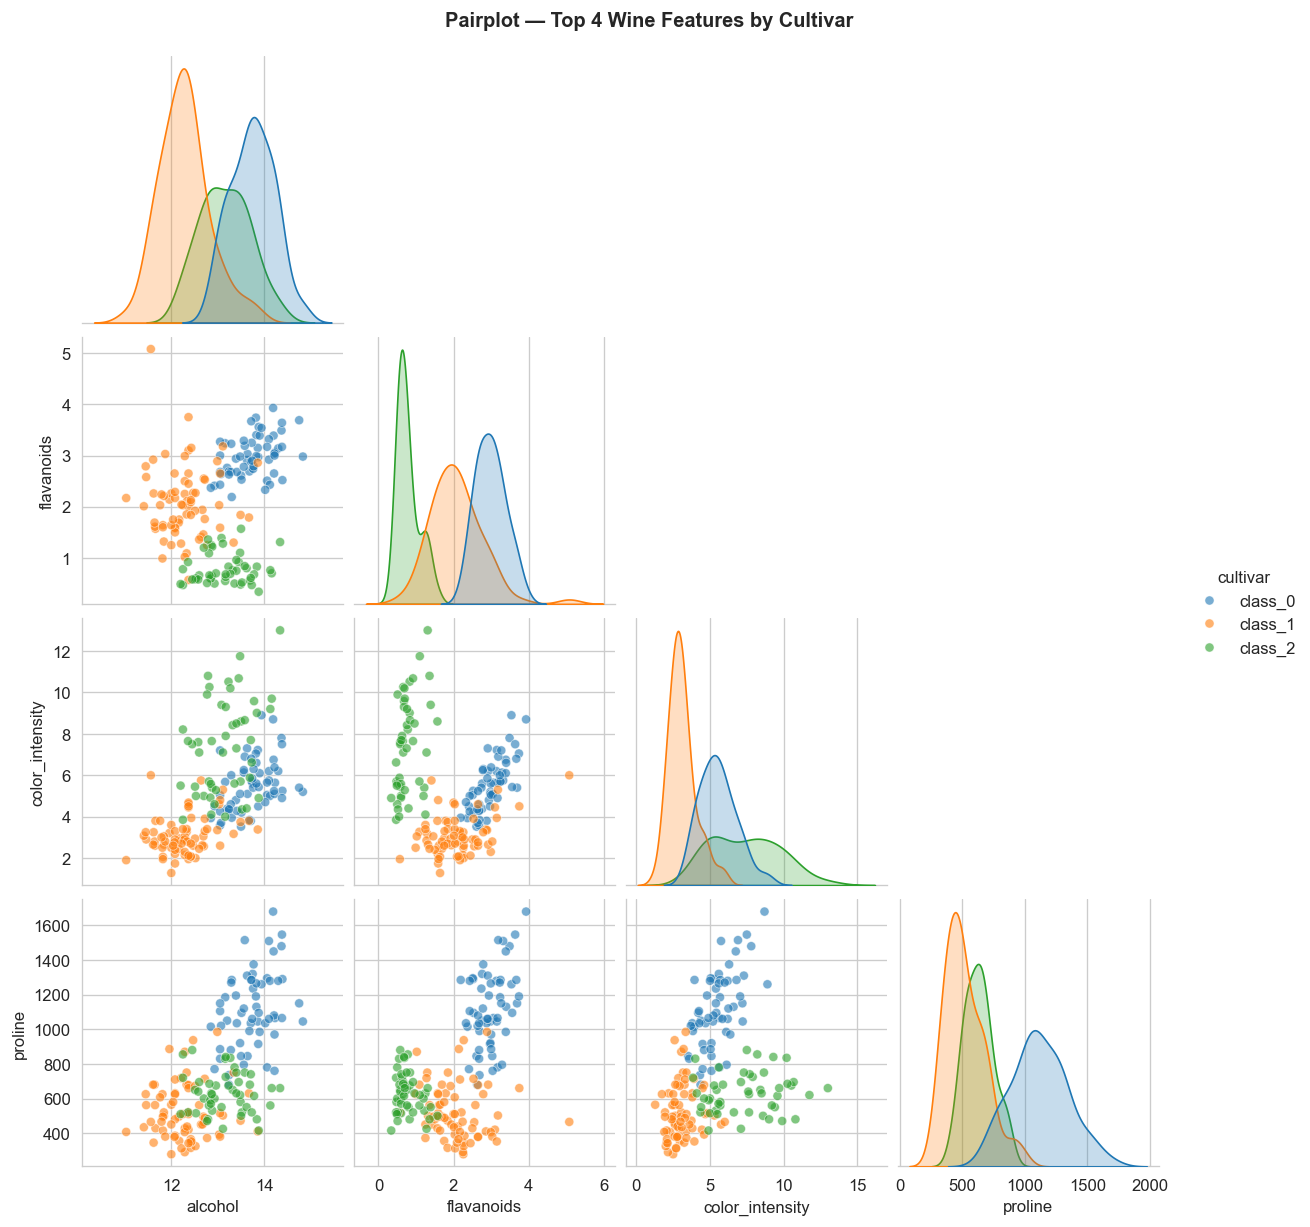


💡 Notice: flavanoids and alcohol already separate the classes quite well!


In [3]:
df_viz = X.copy()
df_viz['cultivar'] = y.map(dict(enumerate(wine.target_names)))

# Pairplot for 4 most informative features (selected by domain knowledge)
top_feats = ['alcohol', 'flavanoids', 'color_intensity', 'proline']

palette = {'class_0': '#e74c3c', 'class_1': '#3498db', 'class_2': '#2ecc71'}
g = sns.pairplot(df_viz[top_feats + ['cultivar']], hue='cultivar',
                 plot_kws={'alpha': 0.6, 's': 30},
                 diag_kind='kde', corner=True)
g.figure.suptitle('Pairplot — Top 4 Wine Features by Cultivar', y=1.02, fontweight='bold')
plt.show()
print("\n💡 Notice: flavanoids and alcohol already separate the classes quite well!")

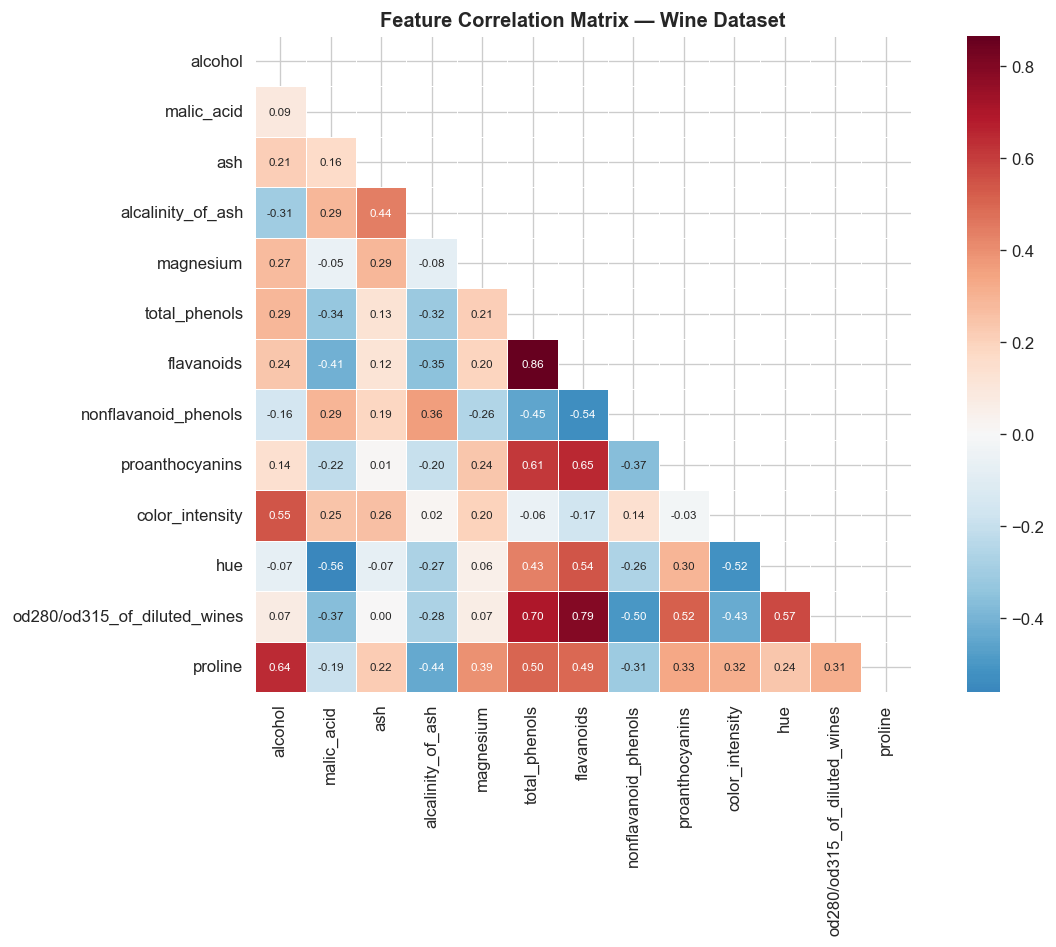

In [4]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(11, 8))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix — Wine Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Gini Impurity — Interactive Calculation

In [5]:
def gini(class_counts):
    """Compute Gini impurity from a list of class counts."""
    total = sum(class_counts)
    if total == 0:
        return 0.0
    return 1 - sum((c / total) ** 2 for c in class_counts)

def info_gain(parent_counts, left_counts, right_counts):
    """Compute Information Gain for a binary split."""
    N = sum(parent_counts)
    N_L, N_R = sum(left_counts), sum(right_counts)
    H_parent = gini(parent_counts)
    H_children = (N_L / N) * gini(left_counts) + (N_R / N) * gini(right_counts)
    return H_parent - H_children

# Example: splitting a dataset of 90 samples (30 per class)
print("=" * 50)
print("EXAMPLE: Wine dataset node with 90 samples")
print("=" * 50)
parent = [30, 30, 30]
print(f"Parent Gini  : {gini(parent):.4f}  (maximally impure — equal classes)")

print("\n--- Candidate Split A: alcohol <= 13.05 ---")
left_A  = [28, 2,  1]   # mostly class 0
right_A = [2,  28, 29]  # mostly classes 1 & 2
print(f"Left child Gini  : {gini(left_A):.4f}")
print(f"Right child Gini : {gini(right_A):.4f}")
print(f"Information Gain : {info_gain(parent, left_A, right_A):.4f} ← Higher is better")

print("\n--- Candidate Split B: color_intensity <= 5.0 ---")
left_B  = [15, 14, 16]  # mixed
right_B = [15, 16, 14]  # mixed
print(f"Left child Gini  : {gini(left_B):.4f}")
print(f"Right child Gini : {gini(right_B):.4f}")
print(f"Information Gain : {info_gain(parent, left_B, right_B):.4f} ← Much lower")

print("\n✅ The tree would choose Split A (alcohol) as it gives more information.")

EXAMPLE: Wine dataset node with 90 samples
Parent Gini  : 0.6667  (maximally impure — equal classes)

--- Candidate Split A: alcohol <= 13.05 ---
Left child Gini  : 0.1790
Right child Gini : 0.5320
Information Gain : 0.2562 ← Higher is better

--- Candidate Split B: color_intensity <= 5.0 ---
Left child Gini  : 0.6657
Right child Gini : 0.6657
Information Gain : 0.0010 ← Much lower

✅ The tree would choose Split A (alcohol) as it gives more information.


## 9. Training a Decision Tree

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# Train with a moderate depth for readability
dt = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt.fit(X_train, y_train)

train_acc = dt.score(X_train, y_train)
test_acc  = dt.score(X_test,  y_test)
print(f"\nDecision Tree (depth=3)")
print(f"  Train accuracy : {train_acc:.3f}")
print(f"  Test  accuracy : {test_acc:.3f}")

print("\n--- Learned Rules ---")
print(export_text(dt, feature_names=list(wine.feature_names)))

Training samples : 133
Test samples     : 45

Decision Tree (depth=3)
  Train accuracy : 0.992
  Test  accuracy : 0.956

--- Learned Rules ---
|--- color_intensity <= 3.82
|   |--- ash <= 3.00
|   |   |--- od280/od315_of_diluted_wines <= 3.73
|   |   |   |--- class: 1
|   |   |--- od280/od315_of_diluted_wines >  3.73
|   |   |   |--- class: 0
|   |--- ash >  3.00
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- alcalinity_of_ash <= 17.65
|   |   |   |--- class: 1
|   |   |--- alcalinity_of_ash >  17.65
|   |   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- proline <= 724.50
|   |   |   |--- class: 1
|   |   |--- proline >  724.50
|   |   |   |--- class: 0



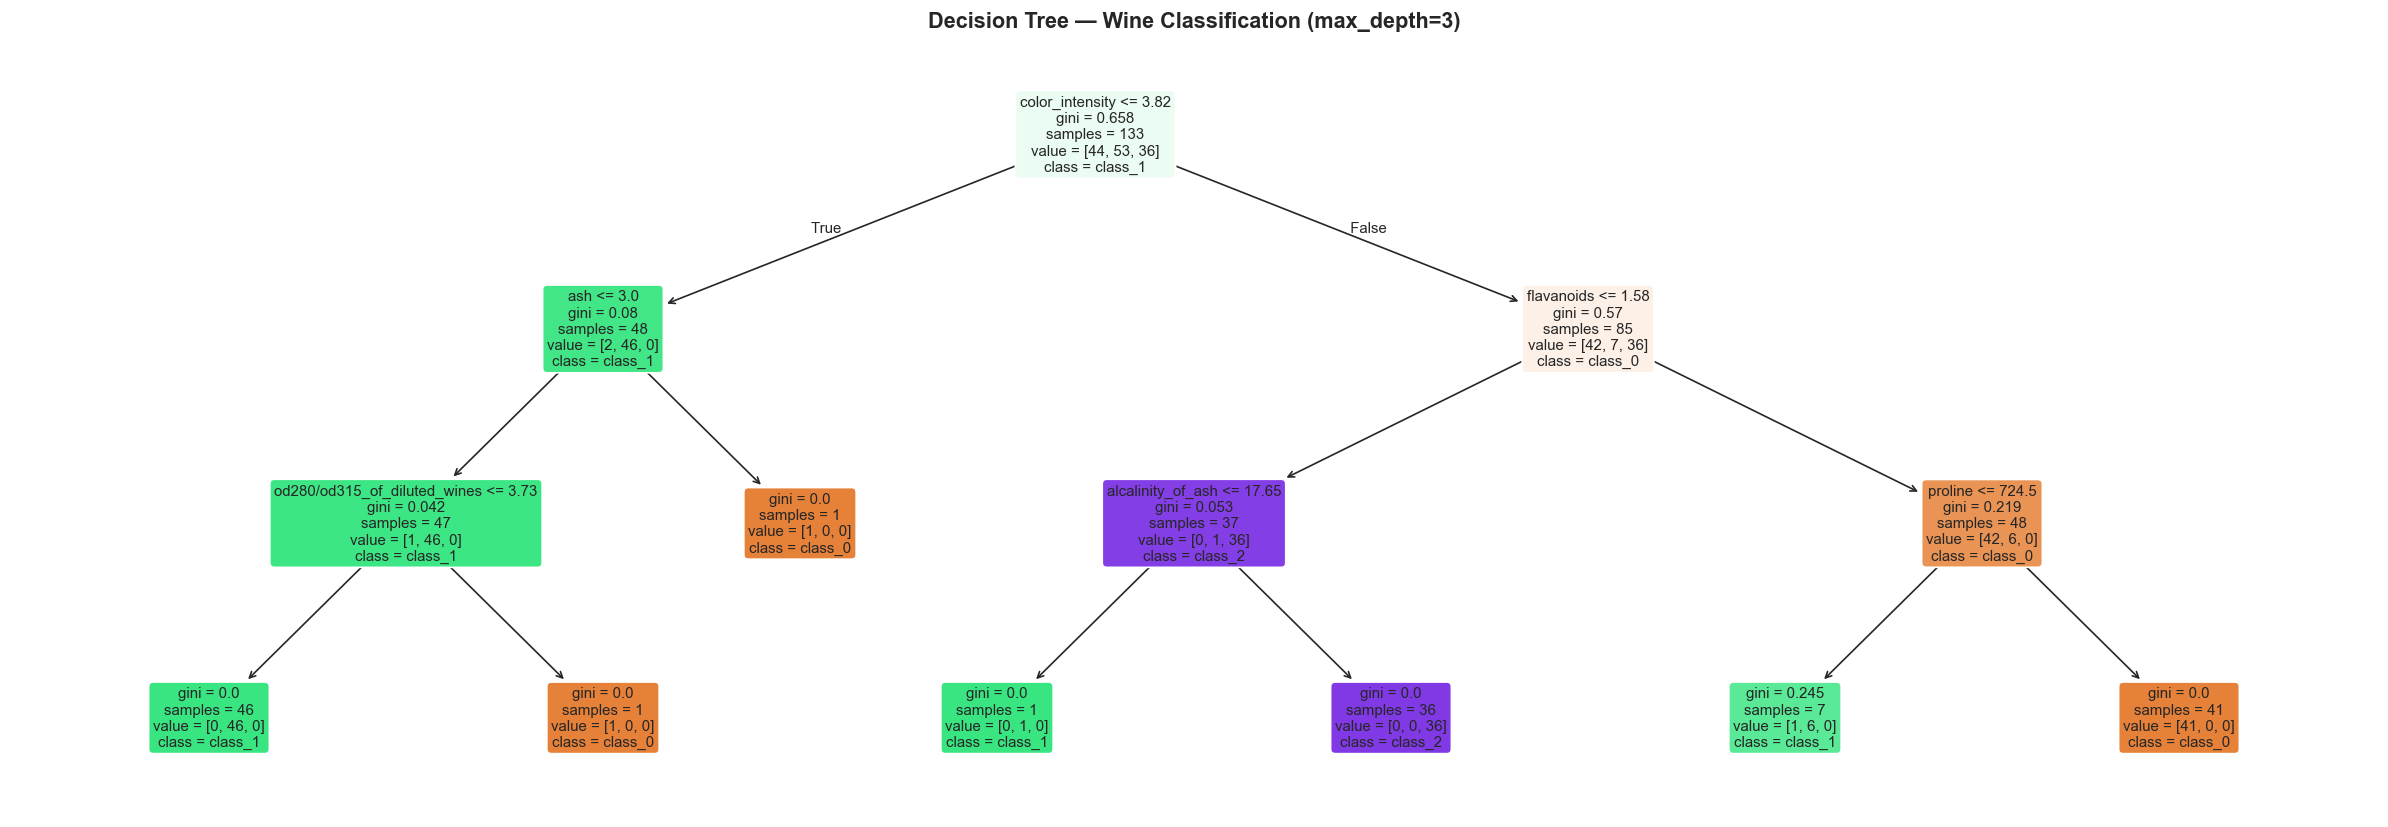

Each node shows: split condition | Gini impurity | sample count | class distribution


In [7]:
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(dt,
          feature_names=wine.feature_names,
          class_names=wine.target_names,
          filled=True, rounded=True,
          fontsize=9, ax=ax,
          impurity=True, proportion=False)
ax.set_title('Decision Tree — Wine Classification (max_depth=3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Each node shows: split condition | Gini impurity | sample count | class distribution")

## 10. Visualising Overfitting

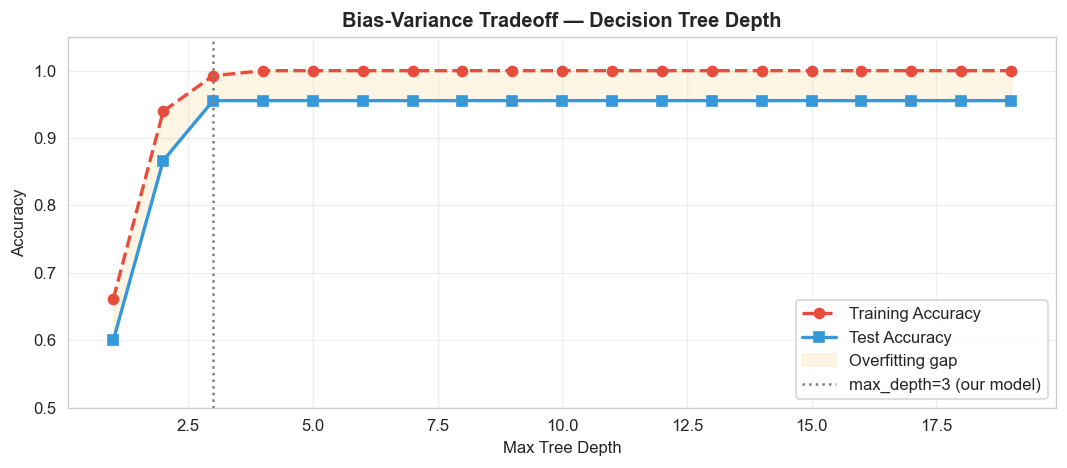

💡 As depth increases, training accuracy → 100% but test accuracy peaks then drops.
   This is the classic overfitting phenomenon.


In [8]:
depths = range(1, 20)
train_accs, test_accs = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(clf.score(X_train, y_train))
    test_accs.append(clf.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_accs, 'o--', color='#e74c3c', label='Training Accuracy', linewidth=2)
ax.plot(depths, test_accs,  's-',  color='#3498db', label='Test Accuracy',     linewidth=2)
ax.fill_between(depths, train_accs, test_accs, alpha=0.1, color='orange', label='Overfitting gap')
ax.axvline(3, color='grey', linestyle=':', label='max_depth=3 (our model)')
ax.set_xlabel('Max Tree Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Bias-Variance Tradeoff — Decision Tree Depth', fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 As depth increases, training accuracy → 100% but test accuracy peaks then drops.")
print("   This is the classic overfitting phenomenon.")

## 11. Training a Random Forest

In [9]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,       # let trees grow fully — forest handles variance
    max_features='sqrt',  # sqrt(13) ≈ 3 features per split
    oob_score=True,       # estimate generalisation without a test set
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

print("Random Forest (100 trees, max_features=sqrt)")
print(f"  Train accuracy    : {rf.score(X_train, y_train):.3f}")
print(f"  Test  accuracy    : {rf.score(X_test,  y_test):.3f}")
print(f"  OOB score         : {rf.oob_score_:.3f}  ← 'free' estimate from unused samples")

cv_scores = cross_val_score(rf, X, y, cv=10, scoring='accuracy')
print(f"  10-Fold CV acc    : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Random Forest (100 trees, max_features=sqrt)
  Train accuracy    : 1.000
  Test  accuracy    : 1.000
  OOB score         : 0.970  ← 'free' estimate from unused samples
  10-Fold CV acc    : 0.983 ± 0.025


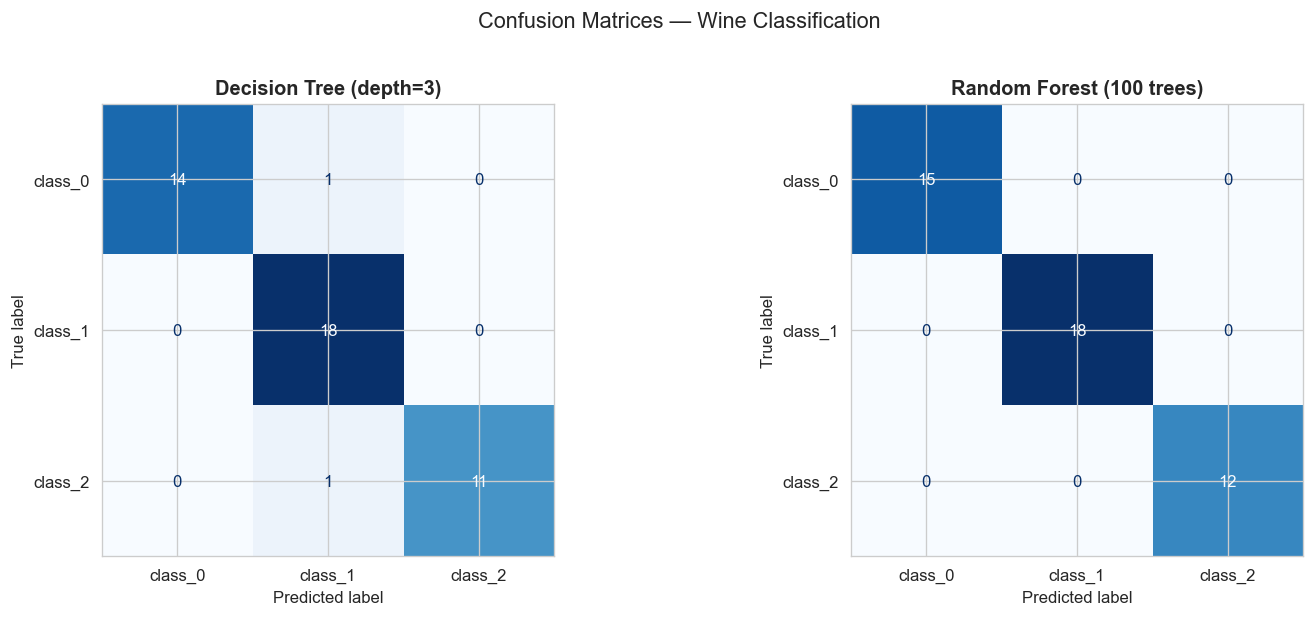


Decision Tree — Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.97        15
     class_1       0.90      1.00      0.95        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45


Random Forest — Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [10]:
# Comparison: Decision Tree vs Random Forest
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title in zip(
    axes,
    [y_pred_dt, y_pred_rf],
    ['Decision Tree (depth=3)', 'Random Forest (100 trees)']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices — Wine Classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nDecision Tree — Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=wine.target_names))
print("\nRandom Forest — Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=wine.target_names))

## 12. Feature Importance

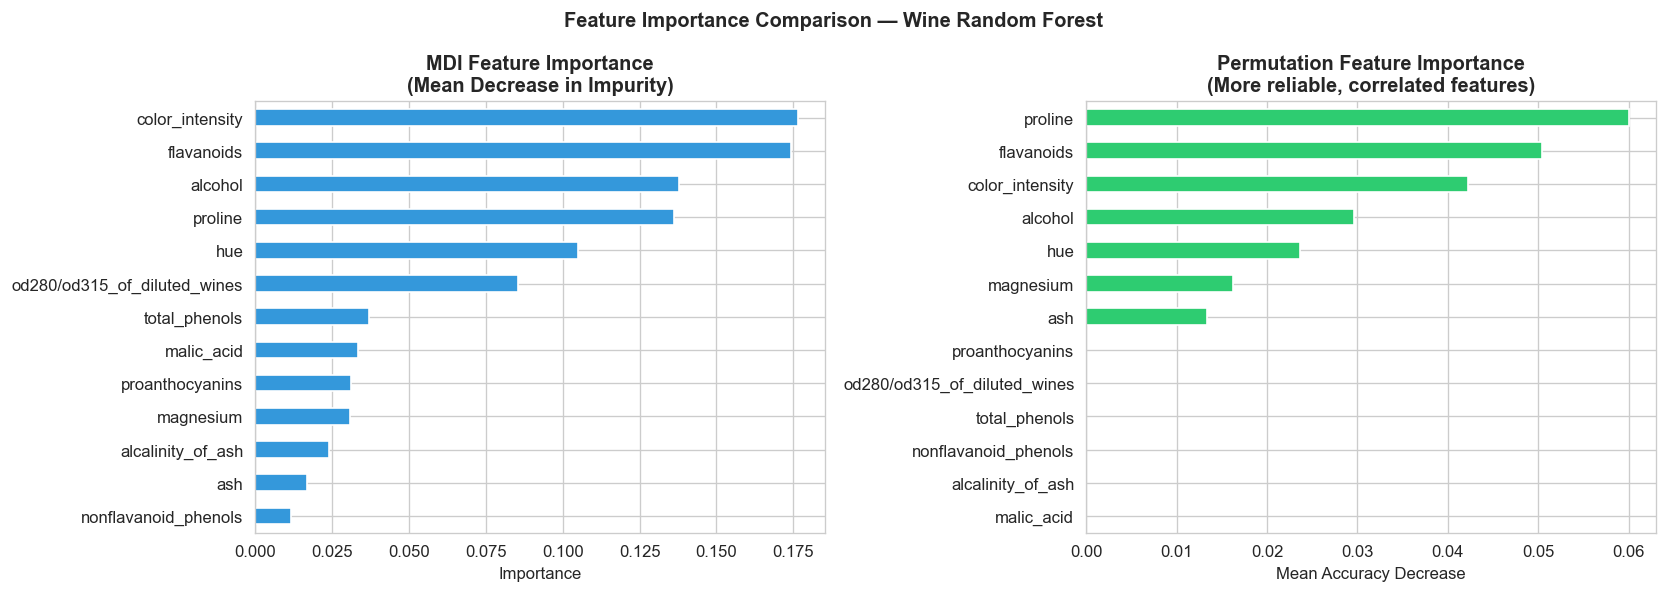


📌 Both methods agree: flavanoids, proline, and alcohol are the top predictors.
   When methods agree = higher confidence in feature ranking.


In [11]:
# Built-in (MDI) importance
fi = pd.Series(rf.feature_importances_, index=wine.feature_names).sort_values()

# Permutation importance (more reliable, especially with correlated features)
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
fi_perm = pd.Series(perm_imp.importances_mean, index=wine.feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('MDI Feature Importance\n(Mean Decrease in Impurity)', fontweight='bold')
axes[0].set_xlabel('Importance')

fi_perm.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Permutation Feature Importance\n(More reliable, correlated features)', fontweight='bold')
axes[1].set_xlabel('Mean Accuracy Decrease')

plt.suptitle('Feature Importance Comparison — Wine Random Forest', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📌 Both methods agree: flavanoids, proline, and alcohol are the top predictors.")
print("   When methods agree = higher confidence in feature ranking.")

## 13. Hyperparameter Tuning with Grid Search

Best hyperparameters: {'max_depth': 4, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV accuracy  : 0.970
Test accuracy     : 1.000


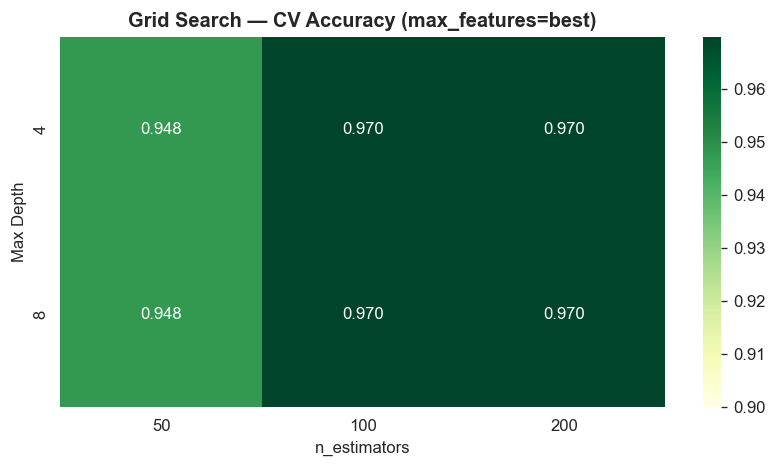

In [12]:
# Grid search on a small grid for illustration
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [4, 8, None],
    'max_features' : ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best CV accuracy  : {grid_search.best_score_:.3f}")
print(f"Test accuracy     : {grid_search.best_estimator_.score(X_test, y_test):.3f}")

# Visualise grid search results
results = pd.DataFrame(grid_search.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax, vmin=0.9)
ax.set_title('Grid Search — CV Accuracy (max_features=best)', fontweight='bold')
ax.set_ylabel('Max Depth')
ax.set_xlabel('n_estimators')
plt.tight_layout()
plt.show()

## 14. Decision Boundary Visualisation (2D Projection)

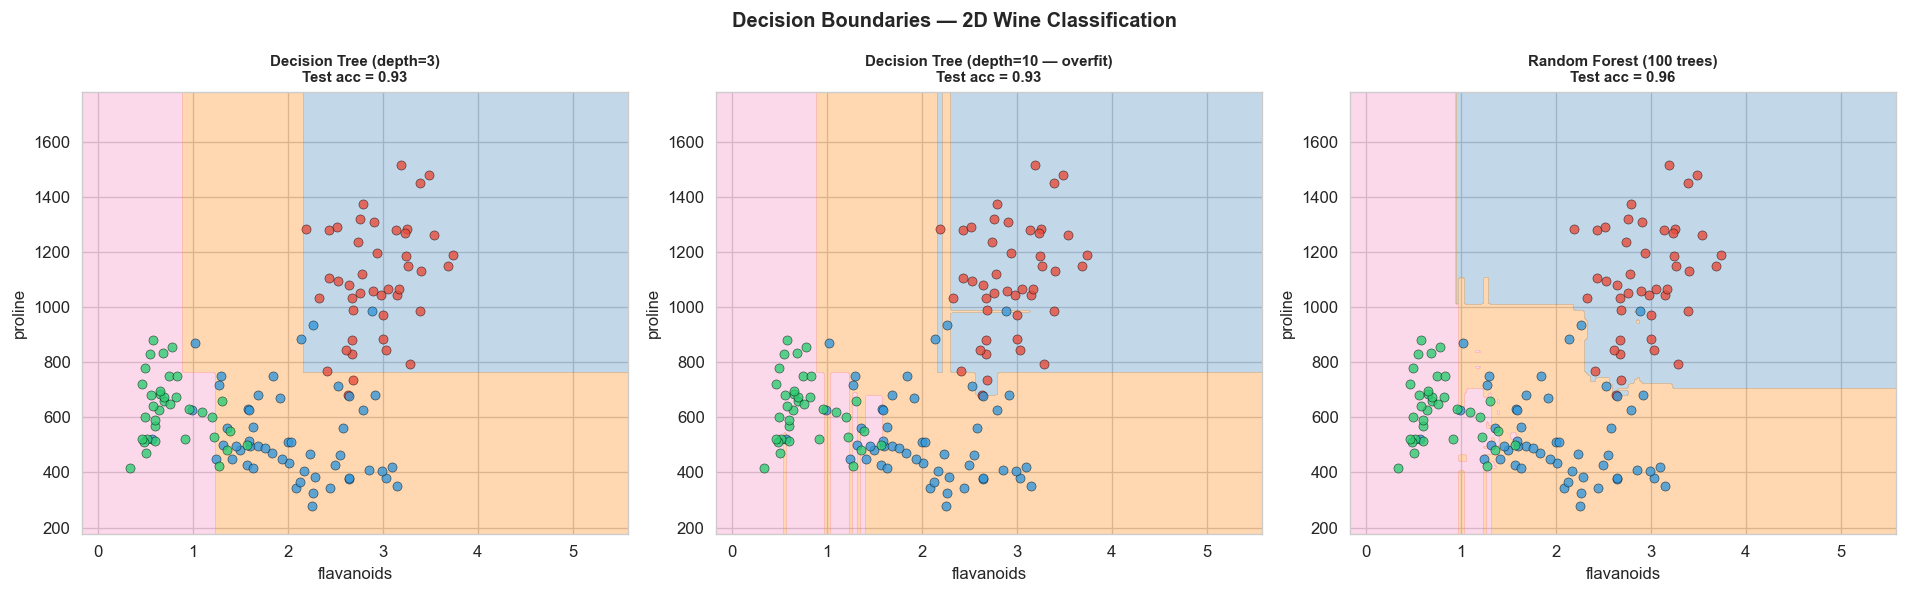


💡 The deep single tree has jagged, 'fragmented' boundaries — a sign of overfitting.
   The Random Forest produces smoother, more generalisable boundaries.


In [13]:
# Use only 2 features to visualise decision boundaries
feat_x, feat_y = 'flavanoids', 'proline'
X2 = X[[feat_x, feat_y]].values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.25, stratify=y, random_state=42)

models = [
    ('Decision Tree (depth=3)', DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('Decision Tree (depth=10 — overfit)', DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('Random Forest (100 trees)', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']
cmap   = plt.cm.RdBu

x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 100, X2[:, 1].max() + 100
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))

for ax, (title, model) in zip(axes, models):
    model.fit(X2_train, y2_train)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1, levels=[-0.5, 0.5, 1.5, 2.5])
    for cls, col in enumerate(colors):
        idx = y2_train == cls
        ax.scatter(X2_train[idx, 0], X2_train[idx, 1], c=col, s=30, alpha=0.8, edgecolors='k', linewidths=0.3)
    acc = model.score(X2_test, y2_test)
    ax.set_title(f'{title}\nTest acc = {acc:.2f}', fontweight='bold', fontsize=9)
    ax.set_xlabel(feat_x)
    ax.set_ylabel(feat_y)

fig.suptitle('Decision Boundaries — 2D Wine Classification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n💡 The deep single tree has jagged, 'fragmented' boundaries — a sign of overfitting.")
print("   The Random Forest produces smoother, more generalisable boundaries.")

## 15. Exercises — Test Your Understanding

Try these modifications and observe the effects:

### Exercise 1 — Criterion Comparison
Change `criterion='gini'` to `criterion='entropy'` in the Decision Tree. Does test accuracy change significantly? Why or why not?

### Exercise 2 — Forest Size
In the Random Forest, change `n_estimators` from 100 to 5, then to 500. Plot accuracy vs. number of trees. What pattern do you see?

### Exercise 3 — Feature Removal
Remove the top-2 most important features and retrain the Random Forest. By how much does accuracy drop? Is the model still useful?

### Exercise 4 — Regression Task
Use `RandomForestRegressor` to predict the `alcohol` column from the remaining features. Evaluate using RMSE and $R^2$.

### Challenge — Your Own Dataset
Find a dataset on [Kaggle](https://www.kaggle.com/) or [UCI ML Repository](https://archive.ics.uci.edu/) and apply the full pipeline from this notebook.

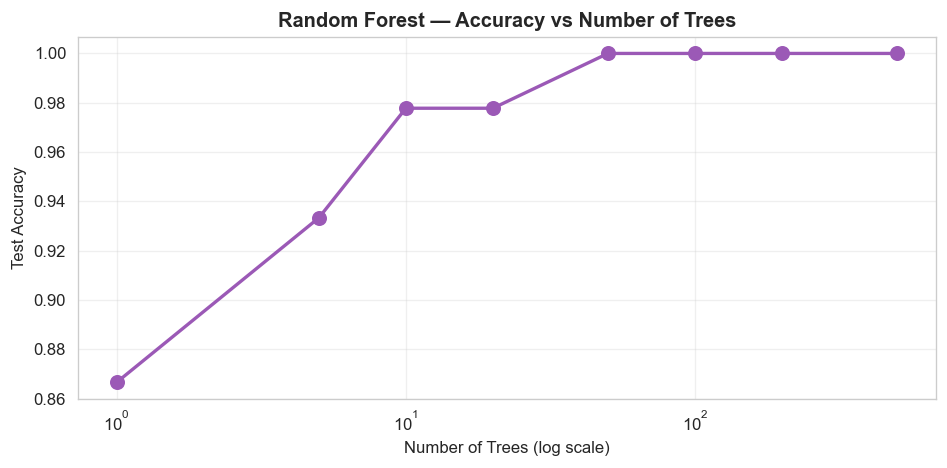


📌 Key insight: accuracy improves rapidly at first, then plateaus — diminishing returns after ~50 trees.


In [14]:
# Exercise 2 starter — forest size vs accuracy
n_trees_range = [1, 5, 10, 20, 50, 100, 200, 500]
accuracies = []

for n in n_trees_range:
    clf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    accuracies.append(clf.score(X_test, y_test))

plt.figure(figsize=(8, 4))
plt.semilogx(n_trees_range, accuracies, 'o-', color='#9b59b6', linewidth=2, markersize=8)
plt.xlabel('Number of Trees (log scale)')
plt.ylabel('Test Accuracy')
plt.title('Random Forest — Accuracy vs Number of Trees', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("\n📌 Key insight: accuracy improves rapidly at first, then plateaus — diminishing returns after ~50 trees.")

## 16. Summary

| | Decision Tree | Random Forest |
|---|---|---|
| **Interpretability** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ |
| **Accuracy** | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Overfitting resistance** | ⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Training speed** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ |
| **Feature importance** | ✅ (rough) | ✅ (MDI + permutation) |
| **No scaling needed** | ✅ | ✅ |
| **Handles missing data** | ⚠️ Limited | ⚠️ Limited |

### When to use what?
- **Decision Tree** → when you need the model to be auditable (medical, legal, regulated industries), as a baseline, or for teaching purposes
- **Random Forest** → most tabular ML tasks as a strong, reliable baseline before trying gradient boosting
- **Consider alternatives** → XGBoost/LightGBM (often outperforms RF on tabular data), Neural Networks (images, text, sequences)

---
### Further Reading
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32.
- James et al. (2021). *An Introduction to Statistical Learning*, Chapter 8 — Tree-Based Methods.
- Hastie et al. (2009). *The Elements of Statistical Learning*, Chapter 9 & 15.
- Scikit-learn documentation: [Decision Trees](https://scikit-learn.org/stable/modules/tree.html)